# Base AE Canonical Target Diagnostics

This notebook checks whether the frozen base autoencoder's embedding space supports the canonical targets used by `train_split_sae_canonical_good.py`.

The main question is whether

```text
0.5 * encode(red image) + 0.5 * encode(green image)
```

decodes like a clean color-neutral digit, or whether it is an off-manifold midpoint that decodes as noise. If the averaged embedding is bad, the split SAE may be faithfully learning a bad canonical target.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_ROOT = PROJECT_ROOT / "src"
for path in [PROJECT_ROOT, SRC_ROOT]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from toy_sae.datasets.colored_mnist import COLOR_NAMES, RGB_PALETTE
from toy_sae.models.base_autoencoder import ConvAutoencoder
from toy_sae.utils.checkpoints import load_checkpoint

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
DEVICE


device(type='mps')

In [2]:
# Config. These defaults match the current split-SAE debugging runs.
BASE_AE_CHECKPOINT = PROJECT_ROOT / "checkpoints/base_ae/best.pt"
SPLIT = "test_balanced"
IMAGE_PATH = PROJECT_ROOT / f"data/colored_mnist/{SPLIT}.npz"
OUT_DIR = PROJECT_ROOT / "outputs/base_ae_canonical_target_diagnostics"

# These are the same example ids that showed noisy good-only reconstructions.
EXAMPLE_INDICES = [6279, 7898, 1059, 8375]

# Use a larger subset for numeric metrics, but keep it small enough for CPU use.
NUM_METRIC_EXAMPLES = 2048
SEED = 0

OUT_DIR.mkdir(parents=True, exist_ok=True)
BASE_AE_CHECKPOINT, IMAGE_PATH, OUT_DIR


(PosixPath('/Users/cuzdu/Desktop/toy-sae/checkpoints/base_ae/best.pt'),
 PosixPath('/Users/cuzdu/Desktop/toy-sae/data/colored_mnist/test_balanced.npz'),
 PosixPath('/Users/cuzdu/Desktop/toy-sae/outputs/base_ae_canonical_target_diagnostics'))

In [3]:
checkpoint = load_checkpoint(BASE_AE_CHECKPOINT)
base_ae = ConvAutoencoder(embedding_dim=int(checkpoint["embedding_dim"]))
base_ae.load_state_dict(checkpoint["model_state_dict"])
base_ae.to(DEVICE)
base_ae.eval()

data = np.load(IMAGE_PATH)
images = data["images"].astype(np.float32)
digits = data["digits"].astype(np.int64)
colors = data["colors"].astype(np.int64)
digit_groups = data["digit_groups"].astype(np.int64)
data.close()

print(f"Loaded {len(images)} images from {IMAGE_PATH.relative_to(PROJECT_ROOT)}")
print(f"Base AE checkpoint: {BASE_AE_CHECKPOINT.relative_to(PROJECT_ROOT)}")
print(f"Device: {DEVICE}")


Loaded 10000 images from data/colored_mnist/test_balanced.npz
Base AE checkpoint: checkpoints/base_ae/best.pt
Device: mps


In [4]:
def foreground_gray(rgb_images):
    """Recover MNIST foreground intensity from colored RGB images."""
    return rgb_images.max(axis=1)


def recolor_images(rgb_images, color_index):
    gray = foreground_gray(rgb_images)
    recolored = gray[..., None] * RGB_PALETTE[color_index][None, None, None, :]
    return np.moveaxis(recolored, -1, 1).astype(np.float32)


def make_gray_images(rgb_images):
    gray = foreground_gray(rgb_images)
    return np.repeat(gray[:, None, :, :], 3, axis=1).astype(np.float32)


@torch.no_grad()
def encode_images(rgb_images, batch_size=512):
    embeddings = []
    for start in range(0, len(rgb_images), batch_size):
        batch = torch.from_numpy(rgb_images[start : start + batch_size]).to(DEVICE)
        embeddings.append(base_ae.encode(batch).cpu())
    return torch.cat(embeddings, dim=0)


@torch.no_grad()
def decode_embeddings(embeddings, batch_size=512):
    decoded = []
    for start in range(0, len(embeddings), batch_size):
        batch = embeddings[start : start + batch_size].to(DEVICE)
        decoded.append(base_ae.decode(batch).cpu())
    return torch.cat(decoded, dim=0).numpy()


def image_mse(a, b):
    return float(np.mean((a - b) ** 2))


def embedding_cycle_mse(embeddings):
    decoded = decode_embeddings(embeddings)
    reencoded = encode_images(decoded)
    return float(torch.mean((reencoded - embeddings.cpu()) ** 2).item())


def foreground_channel_means(decoded_images, reference_images, threshold=0.05):
    mask = foreground_gray(reference_images) > threshold
    means = []
    for channel in range(3):
        values = decoded_images[:, channel][mask]
        means.append(float(values.mean()) if values.size else float("nan"))
    return dict(zip(["red", "green", "blue"], means))


def show_image(ax, image, title):
    ax.imshow(np.clip(np.moveaxis(image, 0, -1), 0.0, 1.0))
    ax.set_title(title, fontsize=9)
    ax.axis("off")


PosixPath('/Users/cuzdu/Desktop/toy-sae/outputs/base_ae_canonical_target_diagnostics/test_balanced_canonical_target_examples.png')

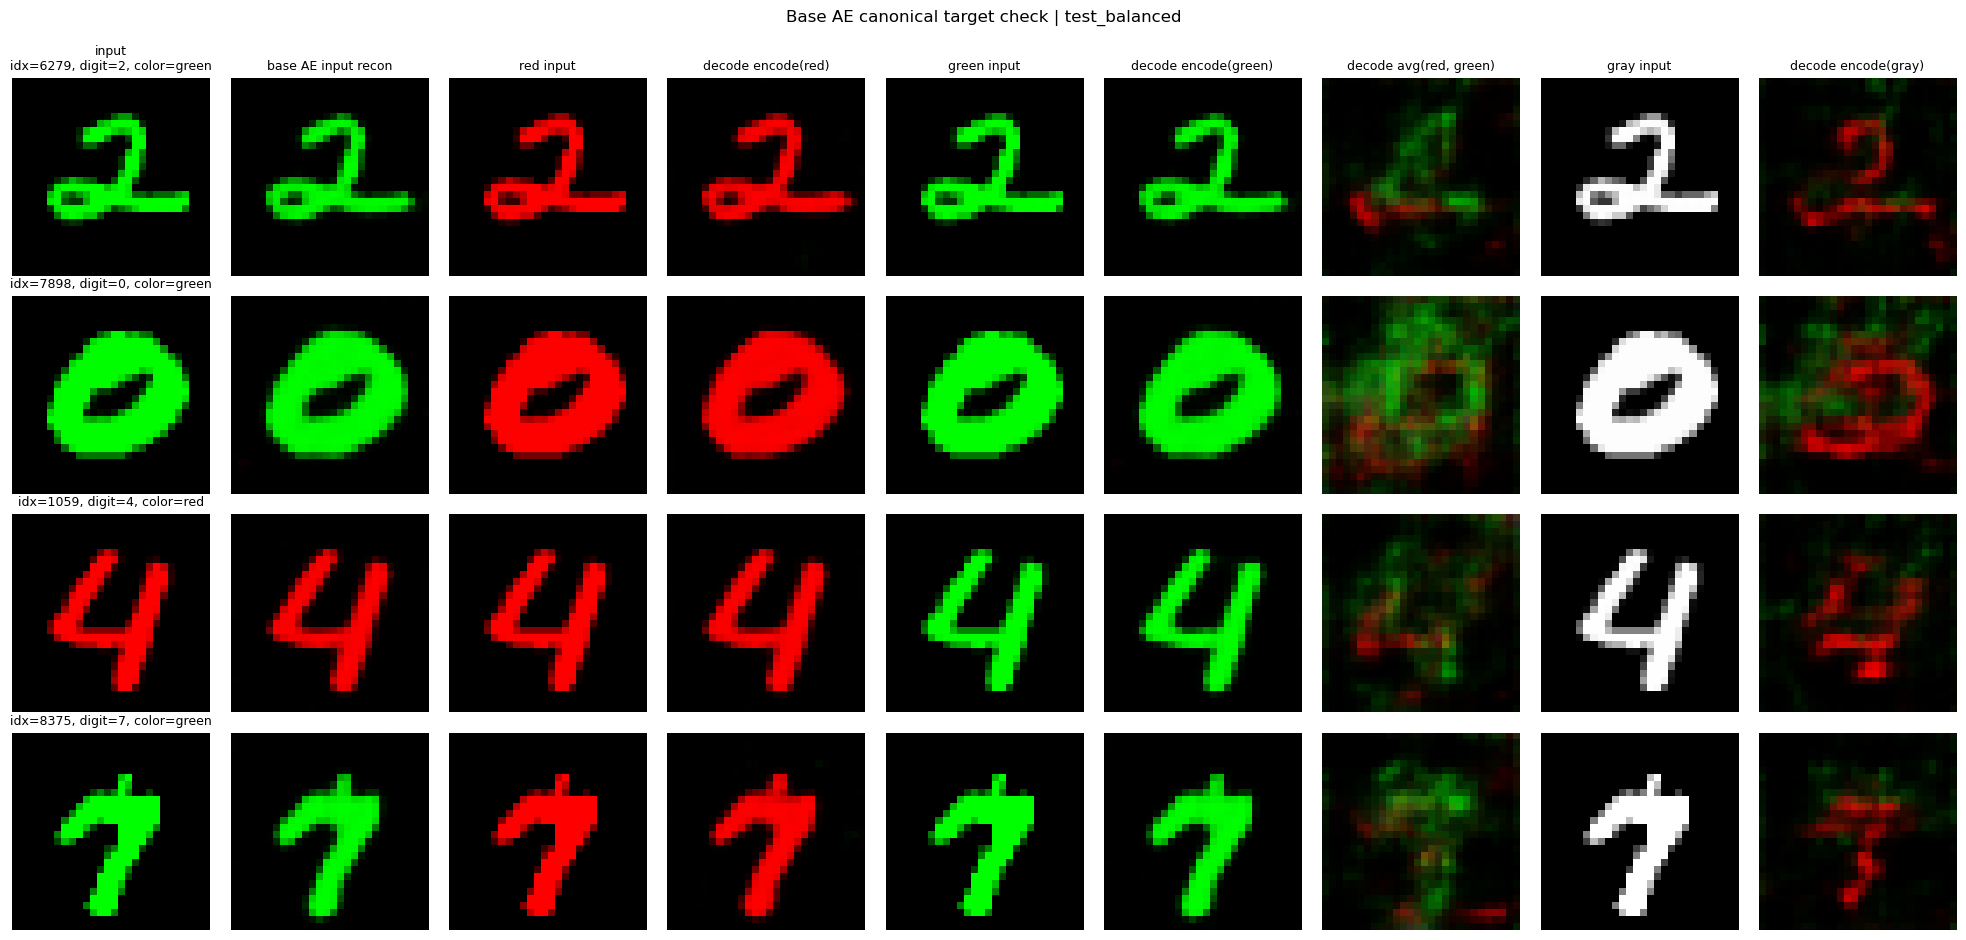

In [5]:
valid_indices = [index for index in EXAMPLE_INDICES if 0 <= index < len(images)]
if not valid_indices:
    rng = np.random.default_rng(SEED)
    valid_indices = rng.choice(len(images), size=4, replace=False).tolist()

example_images = images[valid_indices]
example_red = recolor_images(example_images, 0)
example_green = recolor_images(example_images, 1)
example_gray = make_gray_images(example_images)

emb_red = encode_images(example_red)
emb_green = encode_images(example_green)
emb_gray = encode_images(example_gray)
emb_avg = 0.5 * (emb_red + emb_green)

dec_original = decode_embeddings(encode_images(example_images))
dec_red = decode_embeddings(emb_red)
dec_green = decode_embeddings(emb_green)
dec_gray = decode_embeddings(emb_gray)
dec_avg = decode_embeddings(emb_avg)

columns = [
    ("input", example_images),
    ("base AE input recon", dec_original),
    ("red input", example_red),
    ("decode encode(red)", dec_red),
    ("green input", example_green),
    ("decode encode(green)", dec_green),
    ("decode avg(red, green)", dec_avg),
    ("gray input", example_gray),
    ("decode encode(gray)", dec_gray),
]

fig, axes = plt.subplots(
    len(valid_indices),
    len(columns),
    figsize=(2.2 * len(columns), 2.35 * len(valid_indices)),
)
axes = np.atleast_2d(axes)

for row, index in enumerate(valid_indices):
    label = f"idx={index}, digit={digits[index]}, color={COLOR_NAMES[colors[index]]}"
    for col, (title, batch) in enumerate(columns):
        title_text = title if row == 0 else ""
        if col == 0:
            title_text = f"{title_text}\n{label}" if title_text else label
        show_image(axes[row, col], batch[row], title_text)

fig.suptitle(f"Base AE canonical target check | {SPLIT}", y=0.995)
fig.tight_layout()
figure_path = OUT_DIR / f"{SPLIT}_canonical_target_examples.png"
fig.savefig(figure_path, dpi=160)
figure_path


In [6]:
rng = np.random.default_rng(SEED)
metric_count = min(NUM_METRIC_EXAMPLES, len(images))
metric_indices = rng.choice(len(images), size=metric_count, replace=False)
metric_images = images[metric_indices]
metric_red = recolor_images(metric_images, 0)
metric_green = recolor_images(metric_images, 1)
metric_gray = make_gray_images(metric_images)
metric_pixel_avg = 0.5 * (metric_red + metric_green)

metric_emb_original = encode_images(metric_images)
metric_emb_red = encode_images(metric_red)
metric_emb_green = encode_images(metric_green)
metric_emb_gray = encode_images(metric_gray)
metric_emb_avg = 0.5 * (metric_emb_red + metric_emb_green)

metric_dec_original = decode_embeddings(metric_emb_original)
metric_dec_red = decode_embeddings(metric_emb_red)
metric_dec_green = decode_embeddings(metric_emb_green)
metric_dec_gray = decode_embeddings(metric_emb_gray)
metric_dec_avg = decode_embeddings(metric_emb_avg)

metrics = {
    "split": SPLIT,
    "num_examples": int(metric_count),
    "pixel_mse": {
        "decode_encode_original_vs_original": image_mse(metric_dec_original, metric_images),
        "decode_encode_red_vs_red": image_mse(metric_dec_red, metric_red),
        "decode_encode_green_vs_green": image_mse(metric_dec_green, metric_green),
        "decode_encode_gray_vs_gray": image_mse(metric_dec_gray, metric_gray),
        "decode_avg_embedding_vs_pixel_avg_red_green": image_mse(metric_dec_avg, metric_pixel_avg),
        "decode_avg_embedding_vs_decode_red": image_mse(metric_dec_avg, metric_dec_red),
        "decode_avg_embedding_vs_decode_green": image_mse(metric_dec_avg, metric_dec_green),
        "decode_avg_embedding_vs_decode_gray": image_mse(metric_dec_avg, metric_dec_gray),
    },
    "embedding_cycle_mse": {
        "original": embedding_cycle_mse(metric_emb_original),
        "red": embedding_cycle_mse(metric_emb_red),
        "green": embedding_cycle_mse(metric_emb_green),
        "gray": embedding_cycle_mse(metric_emb_gray),
        "avg_red_green": embedding_cycle_mse(metric_emb_avg),
    },
    "embedding_distance_mse": {
        "red_vs_green": float(torch.mean((metric_emb_red - metric_emb_green) ** 2).item()),
        "red_vs_avg": float(torch.mean((metric_emb_red - metric_emb_avg) ** 2).item()),
        "green_vs_avg": float(torch.mean((metric_emb_green - metric_emb_avg) ** 2).item()),
        "gray_vs_avg": float(torch.mean((metric_emb_gray - metric_emb_avg) ** 2).item()),
    },
    "foreground_channel_means": {
        "decode_red": foreground_channel_means(metric_dec_red, metric_images),
        "decode_green": foreground_channel_means(metric_dec_green, metric_images),
        "decode_gray": foreground_channel_means(metric_dec_gray, metric_images),
        "decode_avg_red_green": foreground_channel_means(metric_dec_avg, metric_images),
    },
}

metrics_path = OUT_DIR / f"{SPLIT}_canonical_target_metrics.json"
with metrics_path.open("w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))
metrics_path


{
  "split": "test_balanced",
  "num_examples": 2048,
  "pixel_mse": {
    "decode_encode_original_vs_original": 0.0006680425722151995,
    "decode_encode_red_vs_red": 0.0006777903181500733,
    "decode_encode_green_vs_green": 0.0006559611647389829,
    "decode_encode_gray_vs_gray": 0.09404859691858292,
    "decode_avg_embedding_vs_pixel_avg_red_green": 0.012875246815383434,
    "decode_avg_embedding_vs_decode_red": 0.03315332531929016,
    "decode_avg_embedding_vs_decode_green": 0.028532033786177635,
    "decode_avg_embedding_vs_decode_gray": 0.006608182564377785
  },
  "embedding_cycle_mse": {
    "original": 0.05021975561976433,
    "red": 0.04863419756293297,
    "green": 0.05158145725727081,
    "gray": 1.680463194847107,
    "avg_red_green": 2.58246111869812
  },
  "embedding_distance_mse": {
    "red_vs_green": 36.52528381347656,
    "red_vs_avg": 9.131319999694824,
    "green_vs_avg": 9.13132095336914,
    "gray_vs_avg": 2.1331093311309814
  },
  "foreground_channel_means": {
 

PosixPath('/Users/cuzdu/Desktop/toy-sae/outputs/base_ae_canonical_target_diagnostics/test_balanced_canonical_target_metrics.json')

## How To Interpret This

Look first at `decode avg(red, green)` in the image grid.

- If `decode encode(red)` and `decode encode(green)` are clean, but `decode avg(red, green)` is blotchy/noisy, then `avg-red-green` is probably off-manifold for the base AE decoder.
- If `decode encode(gray)` is noisy while red/green are clean, gray is out-of-distribution for this base AE.
- If both `avg-red-green` and `gray` decode cleanly, then the poor split-SAE good-only reconstruction is more likely caused by the split objective/architecture than by the canonical target.

For numeric checks, compare `embedding_cycle_mse.avg_red_green` with `red` and `green`. A much larger cycle error for `avg_red_green` means the averaged embedding is not stable under `decode -> encode`, which is a useful off-manifold warning sign.
